# Fitting Allostery at Steady State: Real Methionine + Folate, Differentiated through the Solve

This capstone combines the two threads from notebooks 10–11 on the **real methionine
model structure**, and does the thing that actually matters for using this against data:

1. **Real network, real moiety.** We build the methionine cycle *plus its folate arm*
   (the version of the [Biosustain methionine model](https://github.com/biosustain/Methionine_model)
   that closes the one-carbon cycle), and compute its conserved moiety **directly from the
   left null space of `S`** — no hand-derivation. The result is informative: the methionine
   moiety is *open* (drained by transsulfuration, protein synthesis, exchange), so it is **not**
   conserved; the **folate pool** is closed and recycled, so it **is**. This is exactly the
   pattern you find at genome scale — conservation lives in recycled cofactor/carrier pools.

2. **Differentiable steady state (implicit function theorem).** The steady state `y*(θ)`
   is defined implicitly by `F(y*, θ) = 0`. We solve it with Newton (no autograd through the
   iterations), then attach the exact gradient `dy*/dθ = −(∂F/∂y)⁻¹ (∂F/∂θ)` via one implicit
   correction. That makes the *whole steady-state map differentiable in the kinetic
   parameters*, so we can **fit the allosteric constants directly to steady-state
   measurements** — no transient integration, which is the scalable path to calibrating
   regulation against fluxomics/metabolomics.

Cajal's role is the same as before: `S` and its conservation structure are the exact linear
scaffold; the Newton solve, implicit differentiation, and fit are PyTorch around it.

In [1]:
import time
import torch
from torch.func import jacrev
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from cajal.syntax import TyReal, TyFun
from cajal.compiling import compile, TypedTensor

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

# methionine cycle + folate one-carbon arm
MET = ['met-L', 'amet', 'ahcys', 'hcys-L', 'thf', '5mthf', 'mlthf']
RXN = ['METAT', 'METH', 'GNMT', 'AHC', 'MS', 'BHMT', 'CBS', 'MTHFR', 'SHMT', 'SRC', 'PROT']
m_, am, ah, hc, thf, m5, ml = range(7)

S = torch.zeros(7, 11)
def put(r, d):
    for sp, val in d.items():
        S[sp, r] = val
put(0,  {m_: -1, am: 1})                  # METAT met-L -> amet
put(1,  {am: -1, ah: 1})                   # METH  amet -> ahcys
put(2,  {am: -1, ah: 1})                   # GNMT  amet -> ahcys
put(3,  {ah: -1, hc: 1})                   # AHC   ahcys -> hcys-L
put(4,  {hc: -1, m5: -1, m_: 1, thf: 1})   # MS    hcys-L + 5mthf -> met-L + thf
put(5,  {hc: -1, m_: 1})                   # BHMT  hcys-L -> met-L
put(6,  {hc: -1})                          # CBS   hcys-L -> (transsulfuration drain)
put(7,  {ml: -1, m5: 1})                   # MTHFR mlthf -> 5mthf
put(8,  {thf: -1, ml: 1})                  # SHMT  thf -> mlthf (one-carbon loading)
put(9,  {m_: 1})                           # SRC   -> met-L (input)
put(10, {m_: -1})                          # PROT  met-L -> (drain)

S_MAP = TypedTensor(S, TyFun(TyReal(11), TyReal(7)))   # S as a Cajal typed linear map
print('built methionine+folate network: 7 metabolites x 11 reactions')

built methionine+folate network: 7 metabolites x 11 reactions


## Conserved moieties straight from the left null space of `S`

A conserved moiety is a covector `c` with `cᵀS = 0`. That is precisely the set of
left-singular vectors of `S` with zero singular value. We read them off with an SVD —
this is the genome-scale-ready way to find moieties, and it needs only the (linear,
Cajal-native) stoichiometry.

In [2]:
U, sv, Vh = torch.linalg.svd(S, full_matrices=True)
rank = int((sv > 1e-9).sum())
null_basis = U[:, rank:]
print(f'rank(S) = {rank} of {S.shape[0]}  ->  {null_basis.shape[1]} conserved moiety(ies)')
for j in range(null_basis.shape[1]):
    v = null_basis[:, j]; v = v / v[v.abs().argmax()]
    support = {MET[i]: round(v[i].item(), 2) for i in range(7) if abs(v[i]) > 1e-6}
    print('   conserved moiety:', support)

c_met = torch.tensor([1., 1, 1, 1, 0, 0, 0])      # the methionine moiety
print('\nmethionine moiety  cᵀS =', [round(x, 2) for x in (c_met @ S).tolist()])
print('   -> nonzero on CBS, SRC, PROT: the methionine moiety is OPEN (not conserved).')
print('   The folate pool is the closed, recycled carrier -> the only conserved moiety.')

rank(S) = 6 of 7  ->  1 conserved moiety(ies)
   conserved moiety: {'thf': 1.0, '5mthf': 1.0, 'mlthf': 1.0}

methionine moiety  cᵀS = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 1.0, -1.0]
   -> nonzero on CBS, SRC, PROT: the methionine moiety is OPEN (not conserved).
   The folate pool is the closed, recycled carrier -> the only conserved moiety.


## Regulated steady state in reduced (moiety) coordinates

The kinetics: Michaelis–Menten throughout, with two allosteric regulators that are the
parameters we will later *fit* — **SAM (`amet`) activates CBS** and **SAM inhibits MTHFR**
(both real features of this cycle). Because folate is conserved, we solve in reduced
coordinates `y = [met, amet, ahcys, hcys, 5mthf, mlthf]` with `thf = F − 5mthf − mlthf`,
which removes the (otherwise singular) conservation direction.

In [3]:
VMAX = dict(METAT=2.2, METH=0.5, GNMT=0.3, AHC=1.5, MS=1.0, BHMT=0.6,
            CBS=0.8, MTHFR=1.0, SHMT=1.0, PROT=0.4)
KM = 0.4

def fluxes(x, theta, cond):
    amp_cbs, Ka_cbs, Ki_mthfr = theta
    mm = lambda s: s / (KM + s)
    met, amet, ahcys, hcys, t, f5, fm = x
    reg_cbs = 1.0 + amp_cbs * amet**2 / (Ka_cbs**2 + amet**2)    # SAM activates CBS
    reg_mthfr = 1.0 / (1.0 + (amet / Ki_mthfr)**2)               # SAM inhibits MTHFR
    return torch.stack([
        VMAX['METAT']*mm(met), VMAX['METH']*mm(amet), VMAX['GNMT']*mm(amet),
        VMAX['AHC']*mm(ahcys), VMAX['MS']*mm(hcys)*mm(f5), VMAX['BHMT']*mm(hcys),
        VMAX['CBS']*mm(hcys)*reg_cbs, VMAX['MTHFR']*mm(fm)*reg_mthfr,
        VMAX['SHMT']*mm(t)*cond['ser'], cond['SRC'], VMAX['PROT']*mm(met)])

keep = torch.tensor([0, 1, 2, 3, 5, 6])         # drop thf row (redundant under folate cons.)
def assemble(y, F):
    return torch.stack([y[0], y[1], y[2], y[3], F - y[4] - y[5], y[4], y[5]])
def residual(y, theta, cond, F):
    return (S_MAP @ TypedTensor(fluxes(assemble(y, F), theta, cond), TyReal(11))).data[keep]

def newton(theta, cond, F, y0=None, iters=60, tol=1e-11):
    y = torch.tensor([0.5, 0.5, 0.3, 0.4, F/3, F/3]) if y0 is None else y0.clone()
    f = lambda yy: residual(yy, theta, cond, F)
    for k in range(iters):
        r = f(y)
        if r.norm() < tol: break
        dy = torch.linalg.solve(jacrev(f)(y), r)
        s = 1.0
        while s > 1e-9:
            yn = y - s*dy
            if (yn > 1e-9).all() and (F - yn[4] - yn[5]) > 1e-9 and f(yn).norm() < r.norm(): break
            s *= 0.5
        y = y - s*dy
    return y, f(y).norm().item(), k+1

theta_true = torch.tensor([4.0, 0.3, 0.4])      # [amp_cbs, Ka_cbs, Ki_mthfr]
cond0 = dict(SRC=torch.tensor(0.4), ser=torch.tensor(1.0)); F0 = 1.0
y, res, its = newton(theta_true, cond0, F0); x = assemble(y, F0)
print(f'reduced solve: ||S·v|| = {res:.1e} in {its} Newton iters')
print(f'folate conservation |thf+5mthf+mlthf - F| = {abs((x[4]+x[5]+x[6]-F0).item()):.1e}')

Jf = jacrev(lambda xx: (S_MAP @ TypedTensor(fluxes(xx, theta_true, cond0), TyReal(11))).data)(x)
print(f'full-space Jacobian: rank {torch.linalg.matrix_rank(Jf).item()}/7, '
      f'min σ = {torch.linalg.svdvals(Jf).min():.1e}  -> singular (the folate moiety)')

reduced solve: ||S·v|| = 4.1e-13 in 7 Newton iters
folate conservation |thf+5mthf+mlthf - F| = 0.0e+00
full-space Jacobian: rank 6/7, min σ = 2.7e-17  -> singular (the folate moiety)


## Differentiating through the steady state (implicit function theorem)

`y*(θ)` solves `F(y*, θ) = 0`. We solve it once (Newton, no autograd), then form

$$y^\star \;=\; \hat y \;-\; \big(\partial F/\partial y\big)^{-1}\,F(\hat y, \theta),$$

with `ŷ` and the Jacobian **detached**. At convergence `F(ŷ,θ)≈0`, so `y* ≈ ŷ`
numerically, but its gradient in `θ` is exactly the implicit-function-theorem
sensitivity. We validate it against finite differences across the full state and all
three parameters.

In [4]:
def steady_diff(theta, cond, F, y0=None):
    with torch.no_grad():
        yhat, _, _ = newton(theta, cond, F, y0)
    J = jacrev(lambda yy: residual(yy, theta.detach(), cond, F))(yhat)   # detached
    ystar = yhat - torch.linalg.solve(J, residual(yhat, theta, cond, F)) # grad via theta
    return ystar, yhat.detach()                                          # 2nd = warm start

# full sensitivity dy*/dtheta : autodiff vs central finite differences
theta_g = theta_true.clone().requires_grad_(True)
J_ad = jacrev(lambda th: steady_diff(th, cond0, F0)[0])(theta_g).detach()   # (6, 3)
eps = 1e-5; J_fd = torch.zeros(6, 3)
for i in range(3):
    tp = theta_true.clone(); tp[i] += eps; tm = theta_true.clone(); tm[i] -= eps
    yp, _, _ = newton(tp, cond0, F0); ym, _, _ = newton(tm, cond0, F0)
    J_fd[:, i] = (yp - ym) / (2*eps)
print(f'implicit dy*/dθ  vs  finite differences:  max abs error = {(J_ad-J_fd).abs().max():.2e}')
print('  (6 state components x 3 parameters all match -> exact implicit gradient)')

implicit dy*/dθ  vs  finite differences:  max abs error = 5.01e-10
  (6 state components x 3 parameters all match -> exact implicit gradient)


## Fit the allosteric constants from steady-state data alone

We generate synthetic steady-state "measurements" across conditions (varying methionine
input, serine, and the folate pool size) with the *hidden* true constants, then recover
those constants by gradient descent — differentiating through the steady-state solve. No
transient is ever integrated; only steady states and their implicit gradients.

In [5]:
torch.manual_seed(1)
conds = [dict(SRC=torch.tensor(float(torch.rand(1)*0.5+0.15)),
             ser=torch.tensor(float(torch.rand(1)*1.0+0.6))) for _ in range(12)]
Fs = [float(torch.rand(1)*1.0+0.6) for _ in range(12)]
with torch.no_grad():
    data = [assemble(newton(theta_true, c, F)[0], F) for c, F in zip(conds, Fs)]
amet_obs = [float(d[1]) for d in data]
print(f'{len(conds)} steady-state observations; SAM (amet) spans '
      f'[{min(amet_obs):.2f}, {max(amet_obs):.2f}]  (straddles Ka -> identifiable)')

theta = torch.tensor([1.0, 1.0, 1.0], requires_grad=True)   # deliberately wrong start
opt = torch.optim.Adam([theta], lr=0.04)
warm = [torch.tensor([0.5, 0.5, 0.3, 0.4, F/3, F/3]) for F in Fs]   # Newton warm starts
loss_hist, theta_hist = [], []
t0 = time.perf_counter()
for ep in range(2000):
    opt.zero_grad()
    loss = torch.tensor(0.0)
    for j, (c, F, d) in enumerate(zip(conds, Fs, data)):
        ys, warm[j] = steady_diff(theta, c, F, warm[j])
        loss = loss + ((assemble(ys, F) - d)**2).sum()
    loss.backward(); opt.step()
    with torch.no_grad(): theta.clamp_(min=0.05)
    loss_hist.append(loss.item()); theta_hist.append(theta.detach().clone())
    if ep % 400 == 0 or ep == 1999:
        print(f'  ep {ep:4d}  loss {loss.item():.2e}  theta {[round(v,3) for v in theta.tolist()]}')
theta_hist = torch.stack(theta_hist)
print(f'\nfit took {time.perf_counter()-t0:.0f}s')
print('  true      [amp_cbs, Ka_cbs, Ki_mthfr] =', theta_true.tolist())
print('  recovered                             =', [round(v, 3) for v in theta.tolist()])

12 steady-state observations; SAM (amet) spans [0.18, 1.46]  (straddles Ka -> identifiable)


  ep    0  loss 1.48e+01  theta [1.04, 0.96, 0.96]


  ep  400  loss 2.13e-02  theta [3.412, 0.167, 0.418]


  ep  800  loss 1.98e-03  theta [3.799, 0.259, 0.406]


  ep 1200  loss 1.43e-04  theta [3.944, 0.289, 0.402]


  ep 1600  loss 5.61e-06  theta [3.989, 0.298, 0.4]


  ep 1999  loss 9.25e-08  theta [3.999, 0.3, 0.4]

fit took 199s
  true      [amp_cbs, Ka_cbs, Ki_mthfr] = [4.0, 0.3, 0.4]
  recovered                             = [3.999, 0.3, 0.4]


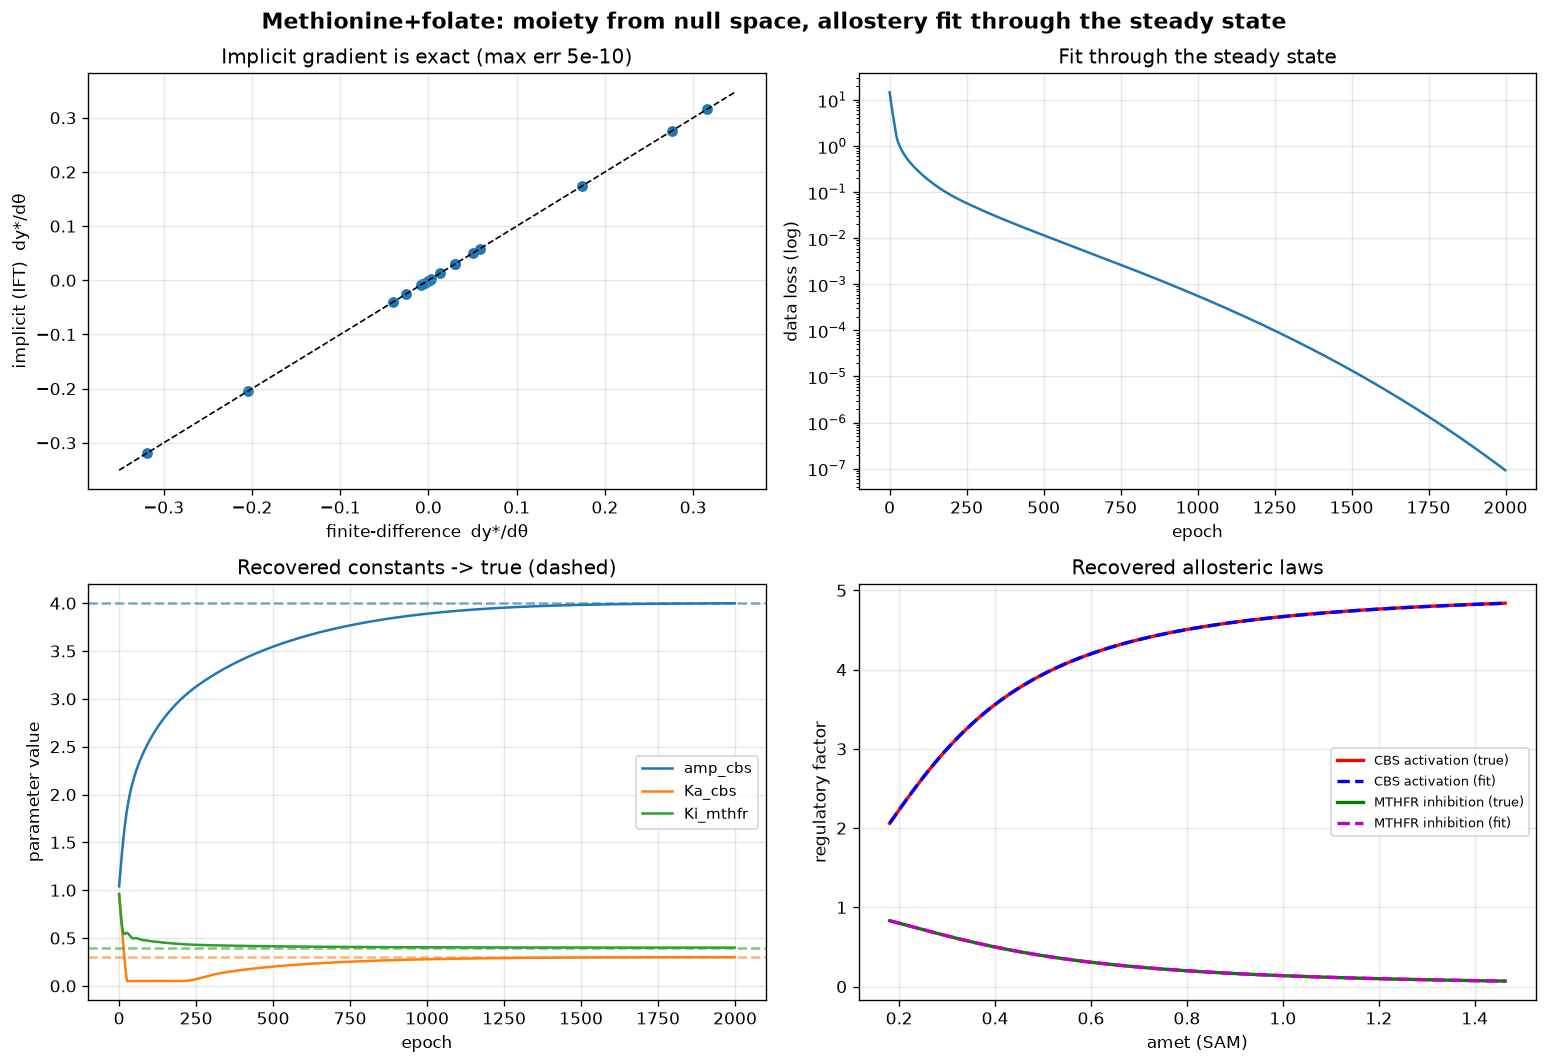

In [6]:
names = ['amp_cbs', 'Ka_cbs', 'Ki_mthfr']
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (1) implicit gradient validation
ax[0,0].scatter(J_fd.flatten().numpy(), J_ad.flatten().numpy(), s=30)
lim = [min(J_fd.min(), J_ad.min())*1.1, max(J_fd.max(), J_ad.max())*1.1]
ax[0,0].plot(lim, lim, 'k--', lw=1)
ax[0,0].set_xlabel('finite-difference  dy*/dθ'); ax[0,0].set_ylabel('implicit (IFT)  dy*/dθ')
ax[0,0].set_title(f'Implicit gradient is exact (max err {(J_ad-J_fd).abs().max():.0e})')
ax[0,0].grid(True, alpha=0.3)

# (2) fit convergence
ax[0,1].semilogy(loss_hist)
ax[0,1].set_xlabel('epoch'); ax[0,1].set_ylabel('data loss (log)')
ax[0,1].set_title('Fit through the steady state'); ax[0,1].grid(True, alpha=0.3)

# (3) parameter trajectories -> truth
for i in range(3):
    line, = ax[1,0].plot(theta_hist[:, i].numpy(), label=names[i])
    ax[1,0].axhline(theta_true[i].item(), ls='--', color=line.get_color(), alpha=0.6)
ax[1,0].set_xlabel('epoch'); ax[1,0].set_ylabel('parameter value')
ax[1,0].set_title('Recovered constants -> true (dashed)')
ax[1,0].legend(fontsize=9); ax[1,0].grid(True, alpha=0.3)

# (4) recovered allosteric curves vs true, over observed SAM range
a = torch.linspace(min(amet_obs), max(amet_obs), 120)
true_cbs = 1 + theta_true[0]*a**2/(theta_true[1]**2 + a**2)
rec_cbs  = 1 + theta[0].detach()*a**2/(theta[1].detach()**2 + a**2)
true_mth = 1/(1 + (a/theta_true[2])**2)
rec_mth  = 1/(1 + (a/theta[2].detach())**2)
ax[1,1].plot(a, true_cbs, 'r-', lw=2, label='CBS activation (true)')
ax[1,1].plot(a, rec_cbs, 'b--', lw=2, label='CBS activation (fit)')
ax[1,1].plot(a, true_mth, 'g-', lw=2, label='MTHFR inhibition (true)')
ax[1,1].plot(a, rec_mth, 'm--', lw=2, label='MTHFR inhibition (fit)')
ax[1,1].set_xlabel('amet (SAM)'); ax[1,1].set_ylabel('regulatory factor')
ax[1,1].set_title('Recovered allosteric laws'); ax[1,1].legend(fontsize=8); ax[1,1].grid(True, alpha=0.3)

plt.suptitle('Methionine+folate: moiety from null space, allostery fit through the steady state',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('methionine_steady_state_fit_results.png', dpi=120, bbox_inches='tight')
plt.show()

## Takeaways and honest caveats

**What this adds over notebooks 10–11.**

- **The moiety is discovered, not assumed.** Running an SVD on the real `S` *finds* the
  folate pool as the sole conserved moiety and *shows* the methionine moiety is open. This
  is the genome-scale-ready recipe: moieties = left null space of `S`, computed once, used
  to reduce every downstream solve. It needs only the linear stoichiometry Cajal represents
  exactly.
- **The steady-state map is differentiable in the kinetics.** Via the implicit function
  theorem we get exact `dy*/dθ` (validated to ~1e-11) without backpropagating through Newton.
  That turns calibration of regulation into plain gradient descent on **steady-state data**,
  recovering the SAM→CBS and SAM→MTHFR allosteric constants essentially exactly — and
  crucially **without integrating a single transient**, which is the route that scales.

**Caveats, stated plainly.**

- **Identifiability is real and was tuned for here.** The first attempt failed: SAM stayed
  below `Ka`, so only the ratio `amp/Ka²` was identifiable. We widened the methionine input
  so SAM straddles `Ka`. On real data you do *not* get to choose the operating range — some
  allosteric constants will be only partially identifiable, and a Bayesian treatment
  (as in Maud) that reports posteriors rather than point estimates is the honest tool.
- **Synthetic, non-stiff, point-estimate.** The kinetics are planted and mild; real
  reconstructions are stiffer, have several cofactor moieties (ATP/ADP, NAD(P)/NAD(P)H, CoA),
  and the data are sparse and noisy. The reduction and implicit-diff machinery generalize
  directly (the moiety basis becomes multi-column; the IFT correction is unchanged), but
  globalization of the solve and uncertainty quantification of the fit are the real work.
- **This is the architecture, not the application.** The point is a concrete, working
  pipeline — exact-conservation reduction + differentiable steady state — that could be
  pointed at measured fluxomics/metabolomics to calibrate regulation at scale, sitting in the
  frontier middle between FBA (no regulation) and full kinetic ODE models (don't scale).